In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("data/dataset.csv")

In [2]:
df.sample(4)

,genero,estado_civil,zona_residencia,imc,fumador,class_etaria,custo
1177,masculino,solteiro,urbana,32.7,nao,adulto_senior,4578.5
996,masculino,viuvo,rural,34.1,nao,adulto_meia_idade,2848.7
513,masculino,solteiro,rural,26.0,nao,adolescente,738.9
1520,feminino,solteiro,suburbana,39.3,nao,idoso,5818.0


In [3]:
df.shape

(2215, 7)

In [4]:
df.describe()

,imc,custo
count,2215.000000,2215.000000
mean,30.704199,6045.710971
std,6.425918,8354.316703
min,3.400000,487.200000
25%,26.150000,2042.200000
50%,30.400000,4050.700000
75%,34.700000,7176.300000
max,83.100000,180544.400000


In [5]:
print(df.isnull().sum())#Verificar valores nulos
print("Quantidade de valores duplicados: ",df.duplicated().sum())

genero             0
estado_civil       0
zona_residencia    0
imc                0
fumador            0
class_etaria       0
custo              0
dtype: int64
Quantidade de valores duplicados:  1


In [6]:
df.drop_duplicates(keep='first',inplace=True) #Eliminar valores duplicados

Text(0, 0.5, 'Custo')

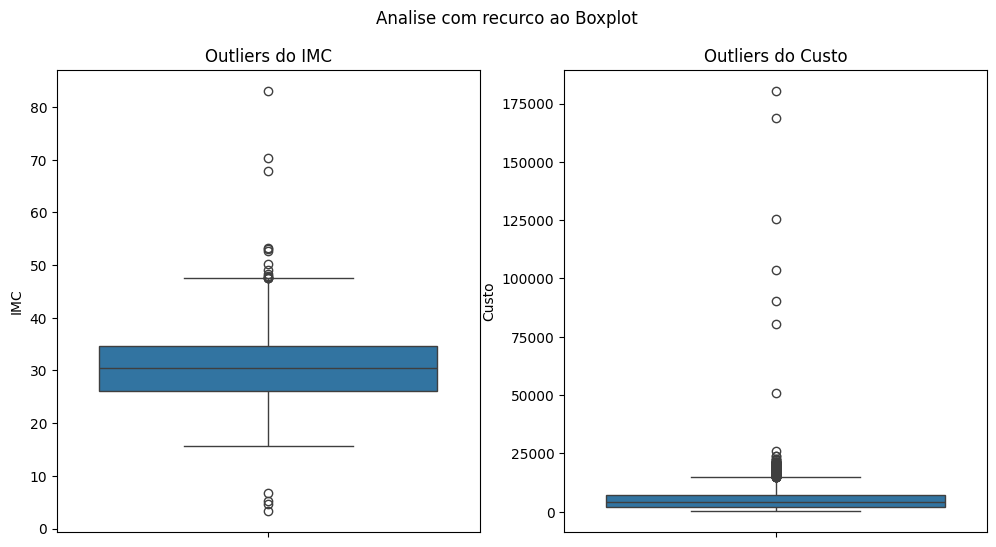

In [7]:
#Analisar possiveis outliers, com o boxplot
plt.figure(figsize=(12,6))
plt.suptitle("Analise com recurco ao Boxplot")

plt.subplot(1,2,1)
sns.boxplot(df,y='imc')
plt.title('Outliers do IMC')
plt.ylabel("IMC")

plt.subplot(1,2,2)
sns.boxplot(df,y='custo')
plt.title('Outliers do Custo')
plt.ylabel("Custo")

In [8]:
### Tratamento de Outliers(ELIMINAÇAO) 

In [9]:
Q1 = df['custo'].quantile(0.25)
Q3 = df['custo'].quantile(0.75)

IQR = Q3 - Q1

fator_3_3 = 3.3 # Não iremos usar o 1.5 pois eliminava demasiados dados. 3.3 foi o valorer que melhor equilibrou os resultados finais.

limite_inferior = Q1 - fator_3_3 * IQR
limite_superior = Q3 + fator_3_3 * IQR

limite_inferior=0
print("Limite inferior (1.5 * IQR): ", limite_inferior) # nao faz sentido ser negativo, por isso ajustamos para zero.
print("Limite superior (1.5 * IQR): ", limite_superior)

Limite inferior (1.5 * IQR):  0
Limite superior (1.5 * IQR):  24132.149999999998


In [10]:
outliers_custo = df[(df['custo'] < limite_inferior) | (df['custo'] > limite_superior)]

print("Quantidade de outliers em 'custo' a ser eliminada: ",outliers_custo.shape[0])
print(outliers_custo[['custo']])

Quantidade de outliers em 'custo' a ser eliminada:  8
         custo
745    26239.5
993   168788.6
1120   50839.8
1307  103539.5
1667   90396.4
1862   80516.1
1973  180544.4
2049  125590.2


In [11]:
##Por ter eliminado estes Outliers o score aumentou de 0.58 para 0.80, apenas eliminando outliers de custo. 

In [12]:
df = df[(df['custo'] >= limite_inferior) & (df['custo'] <= limite_superior)]

In [13]:
##Outliers de imc

In [14]:
#Verificar valores aceitaveis
q1_imc = df['imc'].quantile(0.25)
q3_imc = df['imc'].quantile(0.75)
IQR_imc = q3_imc-q1_imc

limite_inferior = q1_imc -1.5*IQR_imc
limite_superior = q3_imc +1.5*IQR_imc

print("Limite inferior (1.5 * IQR) para 'imc': ", limite_inferior)
print("Limite superior (1.5 * IQR) para 'imc': ", limite_superior)

Limite inferior (1.5 * IQR) para 'imc':  13.350000000000001
Limite superior (1.5 * IQR) para 'imc':  47.35


In [15]:
outliers_imc = df[(df['imc'] < limite_inferior) | (df['imc'] > limite_superior)]
print("Quantidade de outliers no 'imc' a eliminar: ",outliers_imc.shape[0]) #linhas[0] e colunas[1]
print(outliers_imc[['imc']])

Quantidade de outliers no 'imc' a eliminar:  20
       imc
137   47.5
320   67.8
355    4.6
564   47.7
711   47.6
727   83.1
755   50.2
762   53.2
936   48.3
991   47.5
1059   5.3
1083  47.6
1378  52.6
1494   6.7
1591  47.4
1611  49.1
1739  47.9
1773  70.3
1823   3.4
2092  53.1


In [16]:
df.shape

(2206, 7)

In [17]:
#Eliminar os 18 Outliers do imc
df = df[(df['imc'] >= limite_inferior) & (df['imc'] <= limite_superior)]

<Axes: ylabel='imc'>

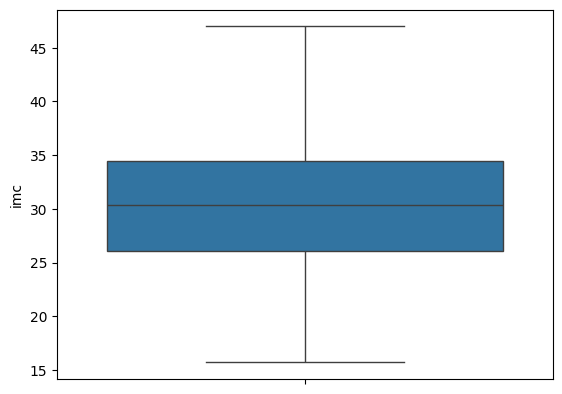

In [18]:
sns.boxplot(data=df['imc'])

In [19]:
#Converter variaveis categoricas binarias em numericas
df['genero'] = df['genero'].map({'masculino': 1, 'feminino': 0})
df['fumador'] = df['fumador'].map({'sim': 1, 'nao': 0})

In [20]:
df.head()

,genero,estado_civil,zona_residencia,imc,fumador,class_etaria,custo
0,1,casado,suburbana,35.8,1,adulto_meia_idade,18213.9
1,0,separado,urbana,39.3,0,adulto_senior,4266.4
2,1,solteiro,rural,40.7,0,jovem,854.6
3,1,casado,urbana,28.2,1,adulto_meia_idade,10169.7
4,0,solteiro,urbana,31.1,0,adulto_senior,4151.5


In [21]:
# dividir dataset
X = df.drop('custo', axis=1)
y = df['custo']

from sklearn.model_selection import train_test_split

Xtrain, Xtest, ytrain, ytest = train_test_split(X, y, test_size=0.25, random_state=8)

In [22]:
X.head()

,genero,estado_civil,zona_residencia,imc,fumador,class_etaria
0,1,casado,suburbana,35.8,1,adulto_meia_idade
1,0,separado,urbana,39.3,0,adulto_senior
2,1,solteiro,rural,40.7,0,jovem
3,1,casado,urbana,28.2,1,adulto_meia_idade
4,0,solteiro,urbana,31.1,0,adulto_senior


In [23]:
#Verificar outras variaveis categoricas
print(df['estado_civil'].unique())
print(df['zona_residencia'].unique())
print(df['class_etaria'].unique())

# 1. Definição das colunas
cat_cols=['estado_civil','zona_residencia','class_etaria']
num_cols = ['imc']
bin_cols = ['genero','fumador'] #Colunas binaricas['genero','fumador']

['casado' 'separado' 'solteiro' 'viuvo']
['suburbana' 'urbana' 'rural']
['adulto_meia_idade' 'adulto_senior' 'jovem' 'idoso' 'adolescente'
 'adulto_jovem']


In [24]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

num_pipeline = Pipeline([
    ('scaler', StandardScaler())
])

cat_pipeline = Pipeline([
    ('OHE', OneHotEncoder(drop='first',handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num_pipeline',num_pipeline,num_cols + bin_cols),
        ('cat_pipeline',cat_pipeline,cat_cols)
    ],
        remainder='passthrough',
        n_jobs=-1
)

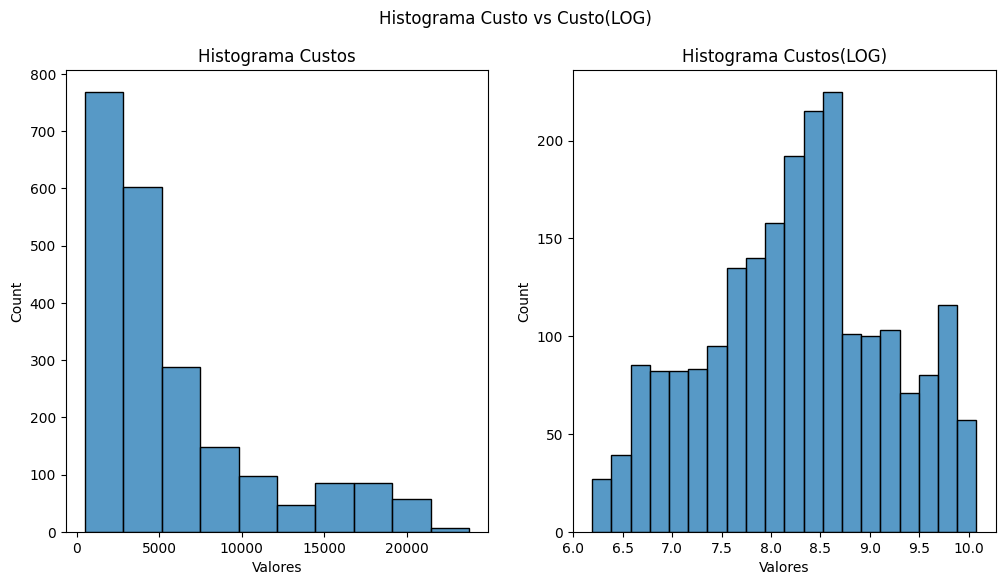

In [25]:
y_log = np.log1p(y)

plt.figure(figsize=(12,6))
plt.suptitle("Histograma Custo vs Custo(LOG)")

plt.subplot(1,2,1)
sns.histplot(x=y,bins=10)
plt.title("Histograma Custos")
plt.xlabel("Valores")

plt.subplot(1,2,2)
sns.histplot(x=y_log,bins=20)
plt.title("Histograma Custos(LOG)")
plt.xlabel("Valores")
plt.show()

In [26]:
#Target contem muitos valores distantes, a imagem indica que vamos utilizar o TransformedTargetRegressor, para normalizar os dados do target.
#Vamos aplicar func=np.log, inverse_func=np.exp

In [27]:
from sklearn.svm import SVR
from sklearn.model_selection import GridSearchCV
from sklearn.compose import TransformedTargetRegressor

pipe_svr = Pipeline([
    ('preprocessor', preprocessor),
    ('model', SVR())
])

# 4. WRAPPER para normalizar o target (y)
# O transformer=StandardScaler() aqui vai normalizar o 'custo' automaticamente
modelo_final = TransformedTargetRegressor(
    regressor=pipe_svr, 
    func=np.log, inverse_func=np.exp,
)

params_grid_svr = [
    #SVR()
    {
        'regressor__model__kernel': ['linear', 'rbf'],
        'regressor__model__C': [1,2,10, 20],
        'regressor__model__epsilon': [0.01, 0.2],
        'regressor__model__gamma': ['scale', 'auto']
    }
]

grid_svr = GridSearchCV(modelo_final,params_grid_svr,cv=5,n_jobs=-1)
grid_svr.fit(Xtrain,ytrain)
print("Melhores parametros: ", grid_svr.best_params_)
print("Acurácia média (CV):", grid_svr.best_score_)

Melhores parametros:  {'regressor__model__C': 2, 'regressor__model__epsilon': 0.2, 'regressor__model__gamma': 'scale', 'regressor__model__kernel': 'rbf'}
Acurácia média (CV): 0.8226882229230726


In [28]:
modelo_otimo=grid_svr.best_estimator_
previsoes = modelo_otimo.predict(Xtest)
t=0
total_elementos = len(previsoes)
for i in range (1 ,11):
    print("Real: ", ytest.iloc[i])
    print("previsto: ",previsoes[i])
    print("***********Diferença: ", (ytest.iloc[i]-previsoes[i]))
    t=t + (ytest.iloc[i]-previsoes[i])

print("Erro Médio nos 10 primeiros: " , t/10," €")

Real:  3091.1
previsto:  4066.259552517683
***********Diferença:  -975.1595525176831
Real:  5228.3
previsto:  5958.006173087682
***********Diferença:  -729.7061730876821
Real:  1829.8
previsto:  1691.11201774923
***********Diferença:  138.6879822507699
Real:  708.2
previsto:  852.0988343826874
***********Diferença:  -143.89883438268737
Real:  18125.7
previsto:  16145.642803432653
***********Diferença:  1980.057196567348
Real:  10095.1
previsto:  9567.71441929574
***********Diferença:  527.3855807042601
Real:  2021.5
previsto:  2362.320974718624
***********Diferença:  -340.8209747186238
Real:  3595.2
previsto:  4385.8641681381305
***********Diferença:  -790.6641681381307
Real:  5275.6
previsto:  4743.6304811209975
***********Diferença:  531.9695188790029
Real:  8389.1
previsto:  7486.934653259296
***********Diferença:  902.1653467407041
Erro Médio nos 10 primeiros:  110.00159222972779  €


In [29]:
from sklearn import metrics

# Explicação: Média das distâncias absolutas entre o real e o previsto.
# Trata todos os erros com o mesmo peso e não permite que erros positivos e negativos se anulem.
mae = metrics.mean_absolute_error(ytest, previsoes)

# Explicação: Raiz quadrada da média dos erros ao quadrado. 
# Ao elevar ao quadrado, "castiga" mais severamente os erros grandes (outliers).
rmse = np.sqrt(metrics.mean_squared_error(ytest, previsoes))

# Explicação: Indica a percentagem da variação dos dados que é explicada pelo modelo.
# 0.88 significa que o modelo explica 88% da variabilidade dos custos
r2 = metrics.r2_score(ytest, previsoes)

print(f"Erro Médio Absoluto (MAE): {mae:.2f} €")
print(f"Erro 'Peso Pesado' (RMSE): {rmse:.2f} €")
print(f"Score R²: {r2:.4f}")

Erro Médio Absoluto (MAE): 1063.23 €
Erro 'Peso Pesado' (RMSE): 1854.05 €
Score R²: 0.8813


In [30]:
from sklearn.metrics import mean_absolute_percentage_error

# 5. MAPE (Mean Absolute Percentage Error)
# Fórmula: (1/n) * Σ |(y_real - y_previsto) / y_real|
# Explicação: Mede o erro como uma percentagem do valor real. 
# Um erro de 19% indica que, em média, a previsão falha por 19% do valor da conta.
mape = mean_absolute_percentage_error(ytest, previsoes)

print(f"Erro Percentual Médio (MAPE): {mape * 100:.2f}%")

Erro Percentual Médio (MAPE): 18.93%


C:\Users\Francisco Guedes\AppData\Local\Temp\ipykernel_13132\2422078437.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(result.importances[sorted_idx].T * 100, vert=False, labels=Xtest.columns[sorted_idx])


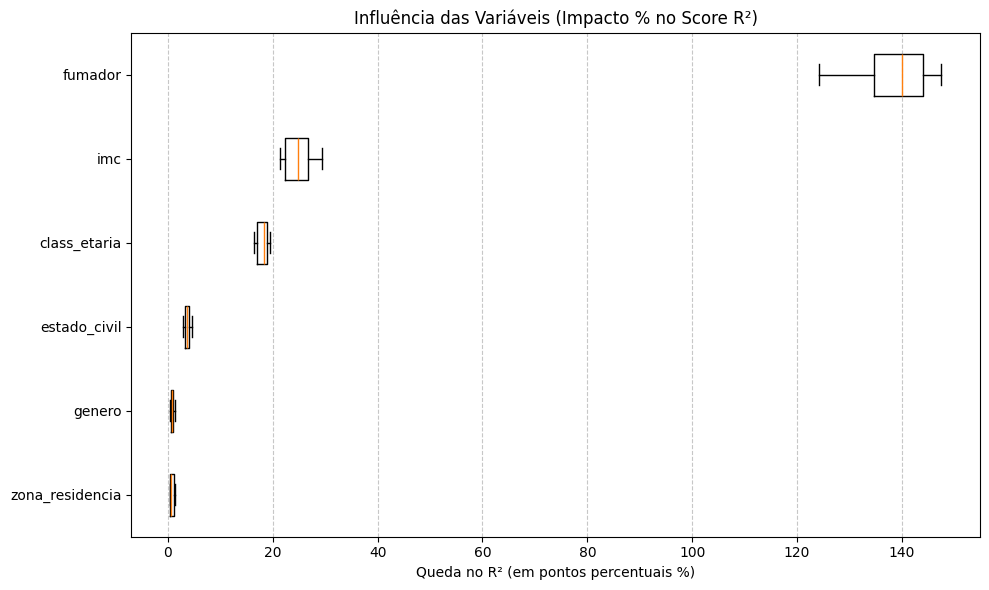

In [31]:
#gerado por GEMINI
from sklearn.inspection import permutation_importance

# 1. Calcular a importância
result = permutation_importance(
    grid_svr.best_estimator_, Xtest, ytest, n_repeats=10, random_state=42, n_jobs=-1
)

# 2. Organizar os índices
sorted_idx = result.importances_mean.argsort()

# 3. Criar o gráfico em Percentagem
plt.figure(figsize=(10, 6))

# Multiplicamos por 100 para converter a escala decimal (0.1) em percentagem (10%)
plt.boxplot(result.importances[sorted_idx].T * 100, vert=False, labels=Xtest.columns[sorted_idx])

plt.title("Influência das Variáveis (Impacto % no Score R²)")
plt.xlabel("Queda no R² (em pontos percentuais %)")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

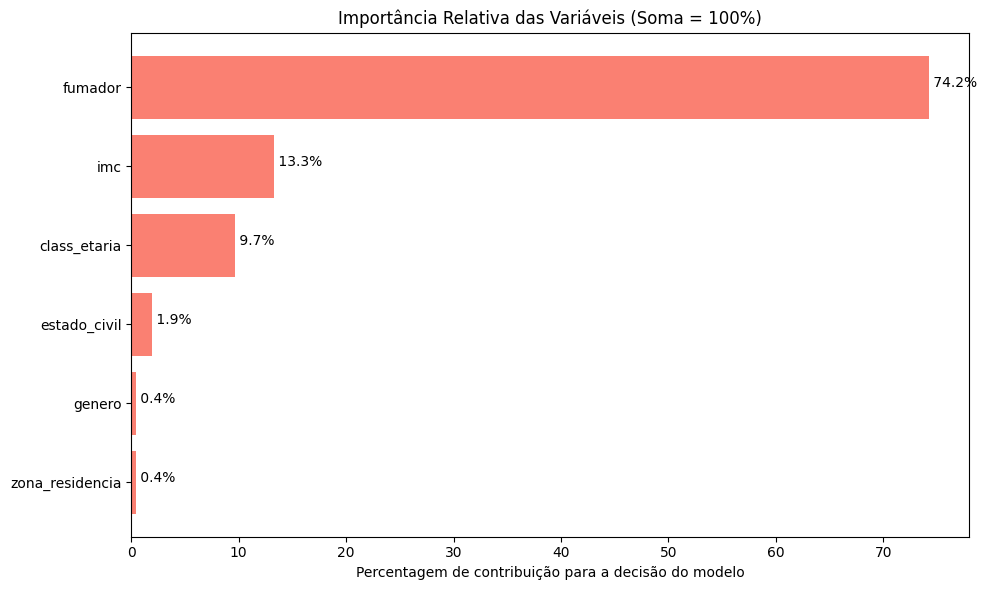

In [32]:
#Gerado por GEMINI
# 1. Calcular a média das importâncias (importances_mean)
importancias_puras = result.importances_mean

# 2. Normalizar para que a soma de tudo seja 100%
# (Dividimos cada uma pela soma total de todas as importâncias)
importancias_normalizadas = (importancias_puras / np.sum(importancias_puras)) * 100

# 3. Organizar os dados
sorted_idx = importancias_normalizadas.argsort()

# 4. Criar o gráfico
plt.figure(figsize=(10, 6))
plt.barh(range(len(sorted_idx)), importancias_normalizadas[sorted_idx], color='salmon')
plt.yticks(range(len(sorted_idx)), [Xtest.columns[i] for i in sorted_idx])

# Adicionar o símbolo de % à frente das barras
for index, value in enumerate(importancias_normalizadas[sorted_idx]):
    plt.text(value, index, f' {value:.1f}%')

plt.title("Importância Relativa das Variáveis (Soma = 100%)")
plt.xlabel("Percentagem de contribuição para a decisão do modelo")
plt.tight_layout()
plt.show()

In [33]:
import joblib
joblib.dump(modelo_otimo, "models/seguros_saude.pkl")

['models/seguros_saude.pkl']